In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("E:\\Data science\\Python\\Matplotlib\\example_set.csv")

#Droping duplicate values
df = df.drop_duplicates()

#Droping cols that don't have product name
df = df.dropna(subset=['Product_Name'])

#Fixing date cols
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors="coerce")
df = df.dropna(subset=['Order_Date'], how='any', axis=0)

#IQR and numeric conversion for numeric cols
cols = ['Age', 'Unit_Price', 'Discount', 'Total_Price', 'Delivery_Days']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df.loc[df[col] < 0, col] = np.nan

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df.loc[(df[col] < lower) | (df[col] > upper), col] = np.nan
    df[col] = df[col].fillna(df[col].median())

#Logical cleaning 
cols2 = ['Customer_Rating', 'Discount', 'Quantity']
for col in cols2:
    df[col] = pd.to_numeric(df[col],errors="coerce")

df.loc[df['Total_Price'] <= 0, 'Total_Price'] = np.nan
df.loc[df['Quantity'] < 1, 'Quantity'] = np.nan
df.loc[((df['Customer_Rating'] < 1) | (df['Customer_Rating'] > 5)), 'Customer_Rating'] = np.nan
df.loc[df['Discount'] > 1, 'Discount'] = np.nan
df = df.dropna(subset=['Customer_Rating', 'Discount', 'Quantity', 'Total_Price'])


#Categorial Data Cleaning
obj_cols = ['Customer_Name', 'Gender', 'City', 'Product_Name', 'Category', 'Payment_Method']

for col in obj_cols:
    df[col] = df[col].str.strip().str.title()

#Feature Engineering
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day_Name'] = df['Order_Date'].dt.day_name()

# print(df.isnull().sum())
# print(df.head())

# print(df.describe())
# print(df.info())


Text(0.5, 1.0, 'Monthly sales trend of year 2024')

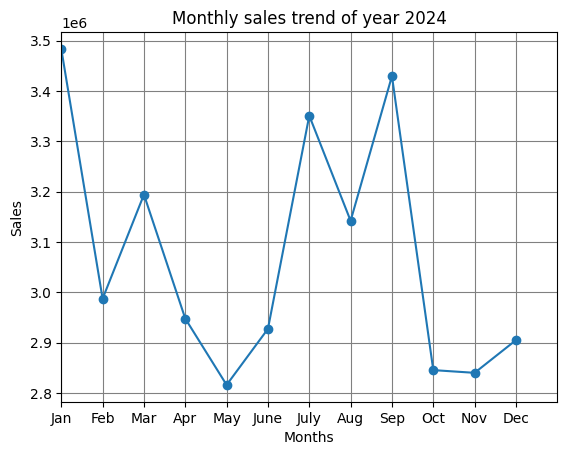

In [52]:
# 1. Create a line chart showing monthly total sales trend.
monthly_sales = df.groupby(['Year','Month'])['Total_Price'].sum().reset_index()
sales_2024 = monthly_sales[monthly_sales['Year'] == 2024]
# print(sales_2024)
plt.plot(['Jan', 'Feb', 'Mar','Apr','May','June','July','Aug','Sep','Oct','Nov','Dec'], sales_2024['Total_Price'], marker='o')
plt.grid(True, color='gray')
plt.xlim([0,12])
plt.xlabel("Months")
plt.ylabel("Sales")
plt.title("Monthly sales trend of year 2024")  

Text(0.5, 1.0, 'Total sales by product category')

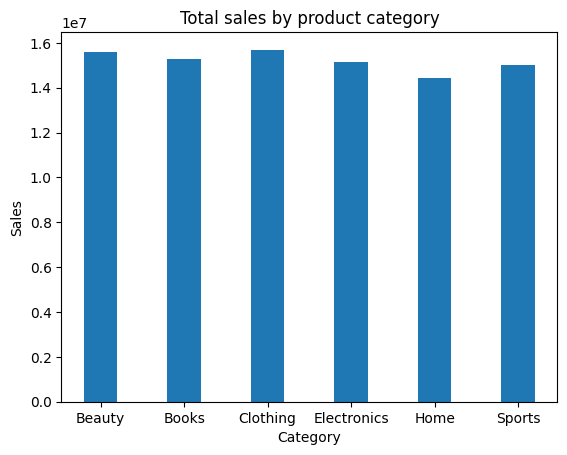

In [53]:
# 2. Create a bar chart of total sales by product category.

groupByCategory = df.groupby('Category')['Total_Price'].sum().reset_index()
# print(groupByCategory)

plt.bar(groupByCategory['Category'], groupByCategory['Total_Price'], width=0.4)
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Total sales by product category")



Text(0.5, 1.0, 'Top 10 highest selling products')

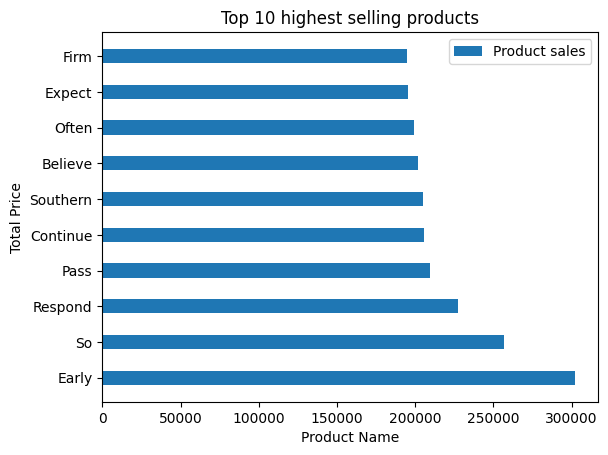

In [54]:
# 3. Create a horizontal bar chart of top 10 highest-selling products.

groupByProduct = df.groupby('Product_Name')['Total_Price'].sum().reset_index().sort_values(by='Total_Price',ascending=False).head(10)
# print(groupByProduct)

plt.barh(groupByProduct['Product_Name'], groupByProduct['Total_Price'], height=0.4, label="Product sales")
plt.legend()
plt.xlabel("Product Name")
plt.ylabel("Total Price")
plt.title("Top 10 highest selling products")

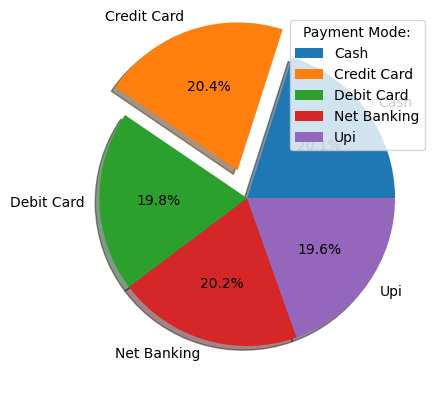

In [55]:
# 4. Create a pie chart showing payment method distribution.

groupBuPymentMethod = df.groupby('Payment_Method')['Order_ID'].count().reset_index()
plt.pie(groupBuPymentMethod['Order_ID'],labels=groupBuPymentMethod['Payment_Method'], shadow=True, autopct='%1.1f%%', explode=[0, 0.2, 0, 0, 0])
plt.legend(title="Payment Mode:")
# print(groupBuPymentMethod)

Text(0.5, 1.0, "Histogram of the people's age")

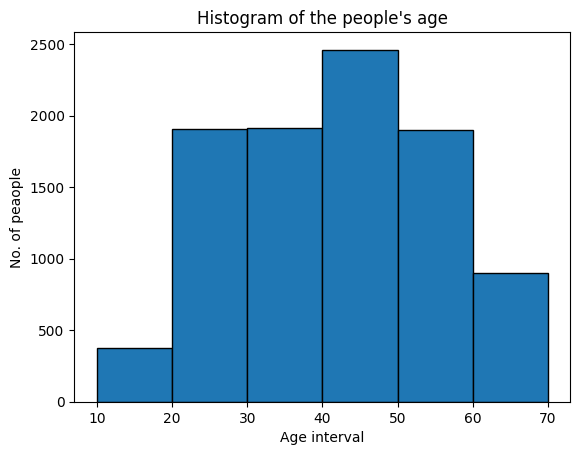

In [56]:
#5. Create a histogram of customer ages.

plt.hist(df['Age'], bins=6, range=[10, 70], edgecolor="black")
plt.xlabel('Age interval')
plt.ylabel("No. of peaople")
plt.title("Histogram of the people's age")


Text(0.5, 1.0, 'Scatter plot between unit price and total price')

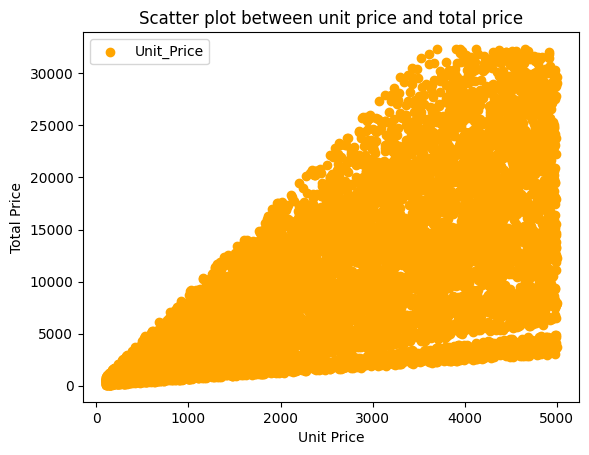

In [57]:
# 6. Create a scatter plot between Unit_Price and Total_Price.
plt.scatter(df['Unit_Price'], df['Total_Price'], marker='o', color='orange', label='Unit_Price')
plt.legend()
plt.xlabel("Unit Price")
plt.ylabel("Total Price")
plt.title("Scatter plot between unit price and total price")

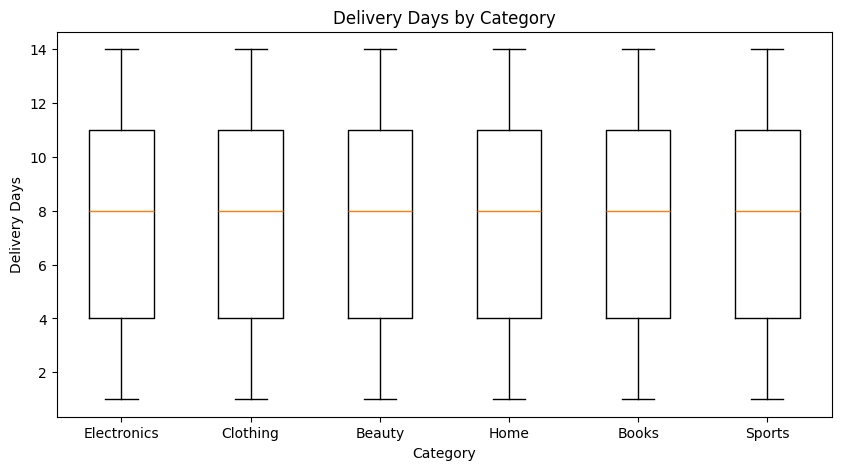

In [58]:
# 7. Create a boxplot for Delivery_Days by Category.
categories = df['Category'].unique()
data = [
    df[df['Category'] == cat]['Delivery_Days']
    for cat in categories
]
plt.figure(figsize=(10,5))

plt.boxplot(data, tick_labels=categories)

plt.xlabel("Category")
plt.ylabel("Delivery Days")

plt.title("Delivery Days by Category")

plt.show()


{'bodies': [<matplotlib.collections.PolyCollection at 0x1786fedbaa0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x1786b901f40>,
 'cmins': <matplotlib.collections.LineCollection at 0x1786b1becf0>,
 'cbars': <matplotlib.collections.LineCollection at 0x1787f0afa40>}

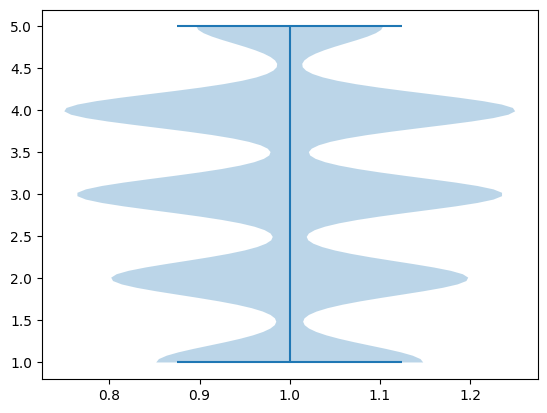

In [59]:
# 8. Create a violin plot for Customer_Rating distribution.
plt.violinplot(df['Customer_Rating'])

<Axes: xlabel='Order_Date'>

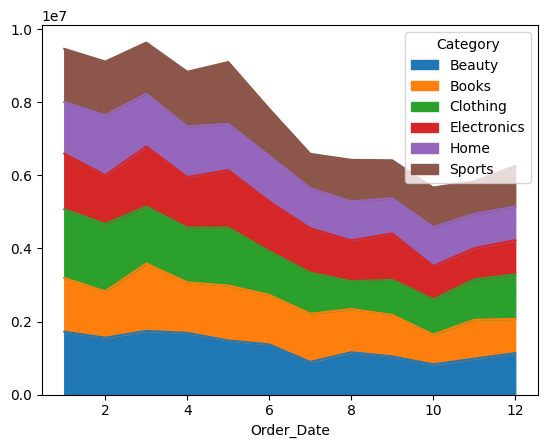

In [60]:
# 9. Create a stacked area chart for category sales over time.
stacked = (
    df.groupby(
        [df['Order_Date'].dt.month, 'Category']
    )['Total_Price']
    .sum()
    .unstack()
)

stacked.plot.area()

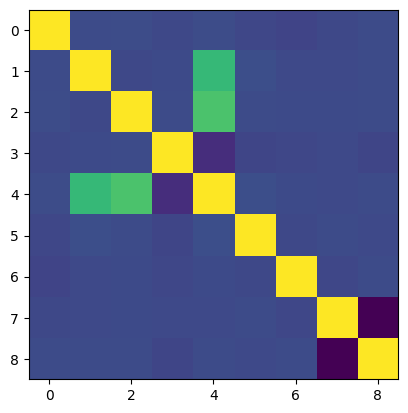

In [61]:
# 10. Create a heatmap of correlation between numerical columns.

corr = df.corr(numeric_only=True)
plt.imshow(corr)

Text(0.5, 1.0, 'Number orders from each cities')

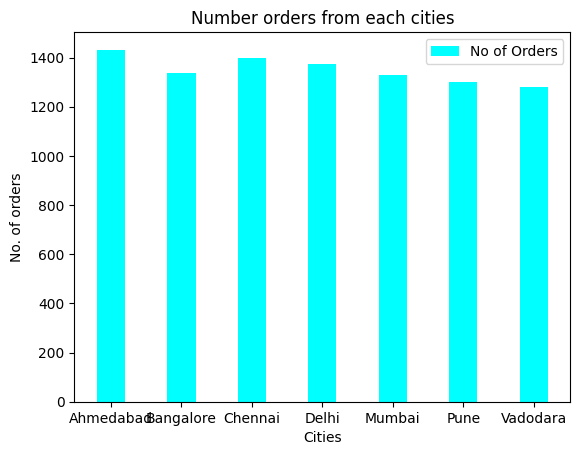

In [62]:
# 11. Create a countplot/bar chart of orders from different cities.

groupByCites = df.groupby('City')['Order_ID'].count().reset_index()
# print(groupByCites)
plt.bar(groupByCites['City'], groupByCites['Order_ID'], width=0.4, label="No of Orders", color='cyan')
plt.xlabel("Cities")
plt.ylabel("No. of orders")
plt.legend()
plt.title("Number orders from each cities")


      Category  Discount
0       Beauty  0.197386
1        Books  0.204047
2     Clothing  0.203003
3  Electronics  0.200725
4         Home  0.205769
5       Sports  0.203955


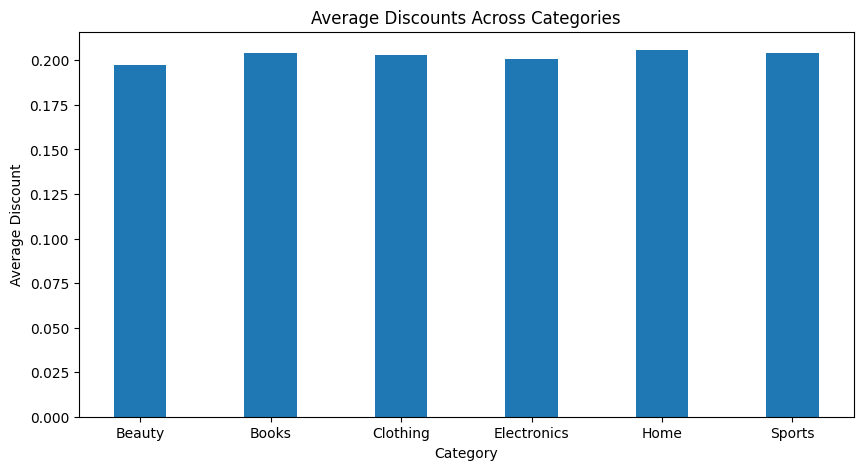

In [63]:
# 12. Compare average discounts across categories using bar plots.

groupByCategory = df.groupby('Category')['Discount'].mean().reset_index()

print(groupByCategory)
plt.figure(figsize=(10,5))

plt.bar(
    groupByCategory['Category'],
    groupByCategory['Discount'],
    width=0.4
)

plt.xlabel("Category")
plt.ylabel("Average Discount")

plt.title("Average Discounts Across Categories")

plt.show()

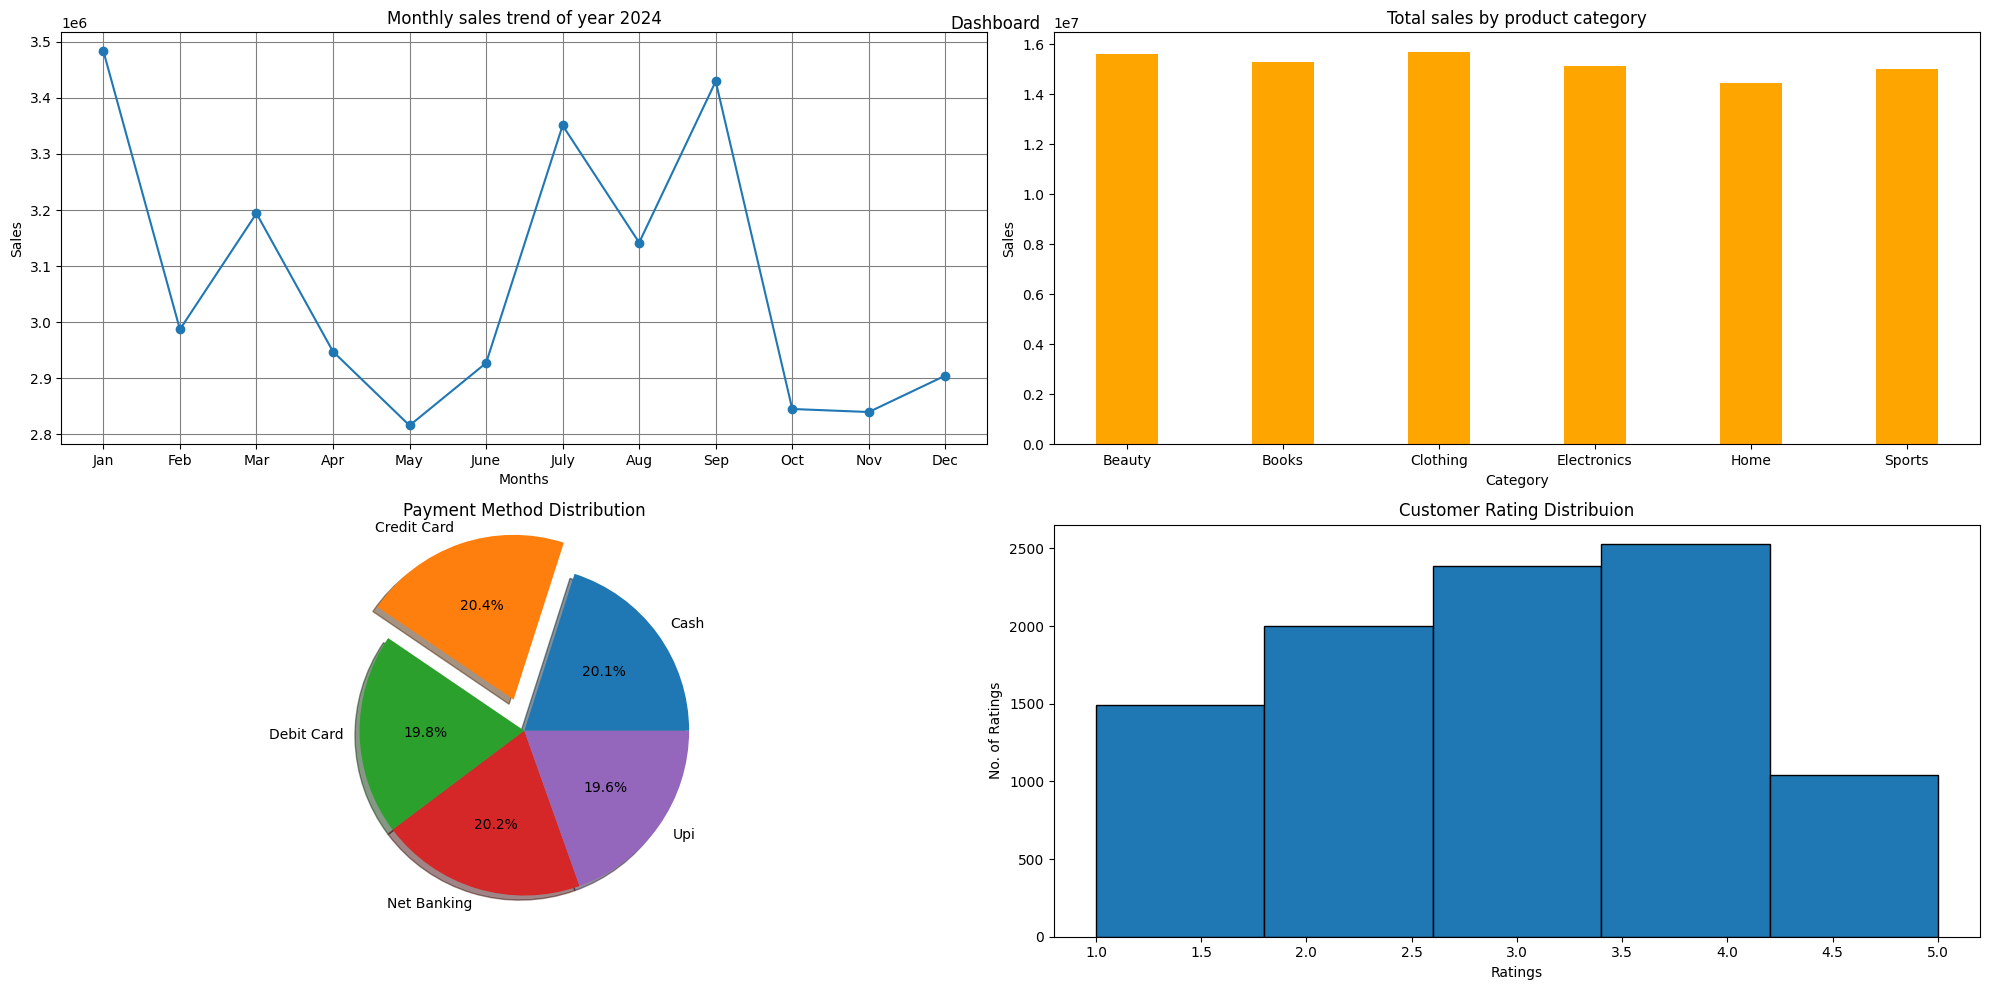

In [64]:
# 13. Create a subplot dashboard with:
#    - Sales trend
#    - Category sales
#    - Payment method distribution
#    - Rating distribution

fig, axes = plt.subplots(2, 2, figsize=[20,10])

#Sales trend
axes[0,0].plot(['Jan', 'Feb', 'Mar','Apr','May','June','July','Aug','Sep','Oct','Nov','Dec'], sales_2024['Total_Price'], marker='o')
axes[0,0].grid(True, color='gray')
axes[0,0].set_xlabel("Months")
axes[0,0].set_ylabel("Sales")
axes[0,0].set_title("Monthly sales trend of year 2024") 

#Category sales
category = df.groupby('Category')['Total_Price'].sum().reset_index()
axes[0,1].bar(category['Category'], category['Total_Price'], width=0.4, color="orange")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Sales")
axes[0,1].set_title("Total sales by product category")

#Payment Method Distribution
axes[1,0].pie(groupBuPymentMethod['Order_ID'],labels=groupBuPymentMethod['Payment_Method'], shadow=True, autopct='%1.1f%%', explode=[0, 0.2, 0, 0, 0])
axes[1,0].set_title("Payment Method Distribution")


#Customer rating distribution
axes[1,1].hist(
    df['Customer_Rating'],
    bins=5,
    range=[1,5],
    edgecolor="black"
)
axes[1,1].set_xlabel("Ratings")
axes[1,1].set_ylabel("No. of Ratings")
axes[1,1].set_title("Customer Rating Distribuion")

plt.tight_layout()
plt.suptitle('Dashboard')

plt.show()

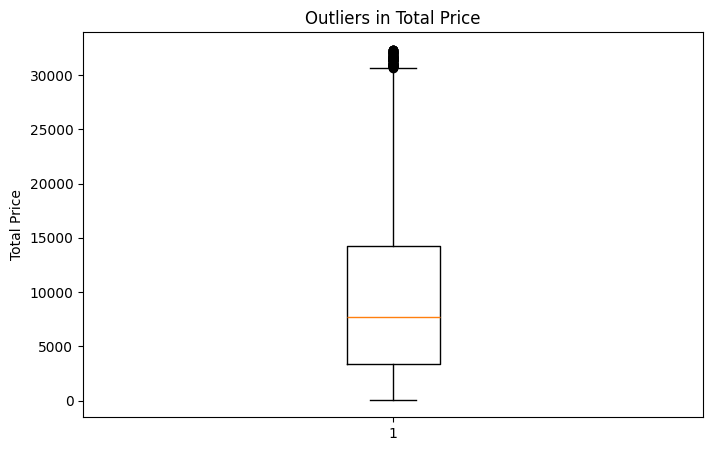

In [65]:
# 14. Find outliers in Total_Price using boxplot.

plt.figure(figsize=(8,5))

plt.boxplot(df['Total_Price'])

plt.title("Outliers in Total Price")

plt.ylabel("Total Price")

plt.show()

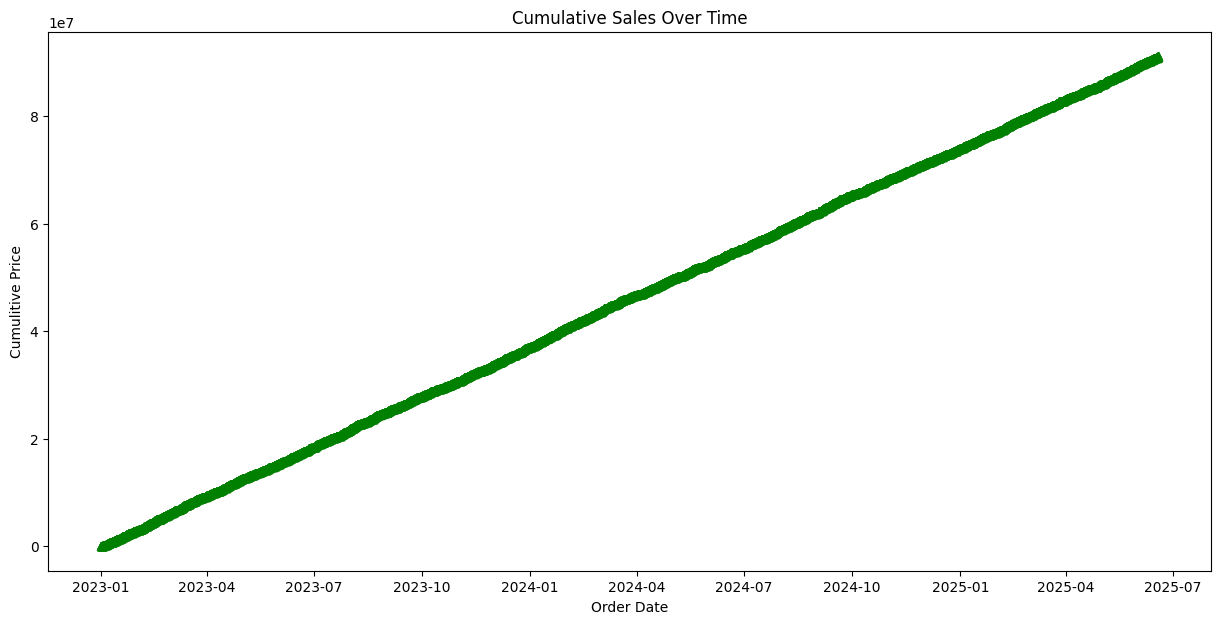

In [66]:
# 15. Create a cumulative sales graph over time.
df = df.sort_values(by="Order_Date", ascending=True)
df["Cumalitive Price"] = df['Total_Price'].cumsum()
plt.figure(figsize=[15,7])
plt.plot(df['Order_Date'], df['Cumalitive Price'], marker='^', color="green")
plt.xlabel("Order Date")
plt.ylabel("Cumulitive Price")
plt.title("Cumulative Sales Over Time")
plt.show()

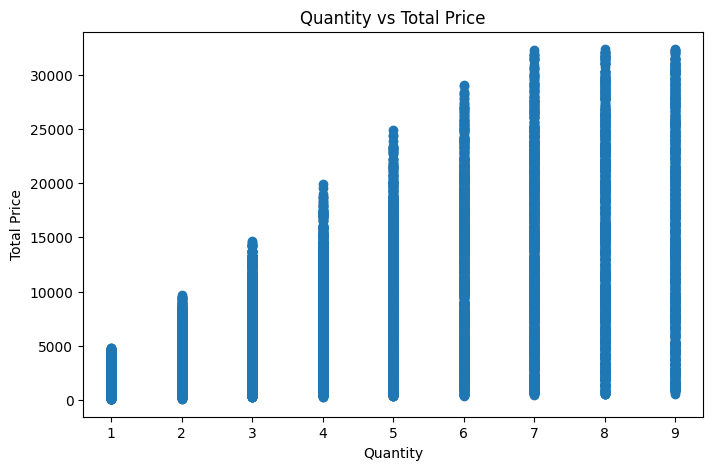

In [67]:
# 16. Visualize relationship between Quantity and Total_Price.

plt.figure(figsize=(8,5))

plt.scatter(
    df['Quantity'],
    df['Total_Price']
)

plt.xlabel("Quantity")
plt.ylabel("Total Price")

plt.title("Quantity vs Total Price")

plt.show()

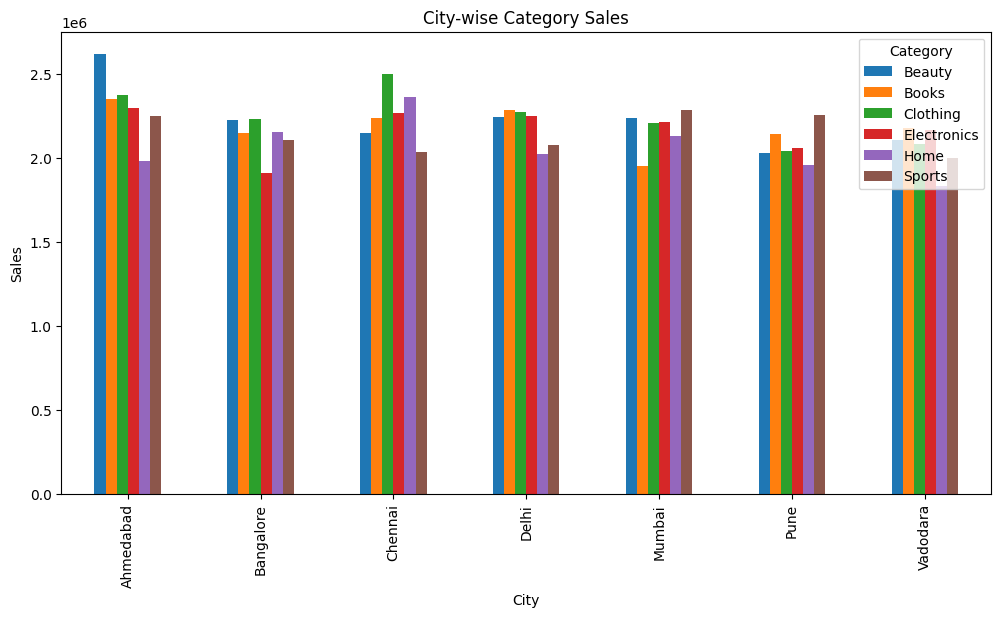

In [68]:
# 17. Create grouped bar charts comparing city-wise category sales.
grouped = (
    df.groupby(['City','Category'])
      ['Total_Price']
      .sum()
      .unstack()
)
grouped.plot(kind='bar', figsize=(12,6))

plt.title("City-wise Category Sales")

plt.ylabel("Sales")

plt.show()


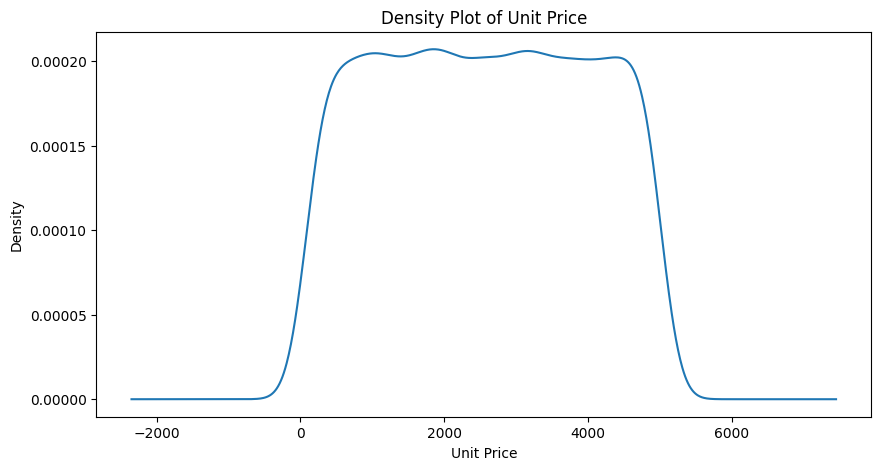

In [69]:
# 18. Create a density plot/KDE plot for Unit_Price.

plt.figure(figsize=(10,5))

df['Unit_Price'].plot.kde()

plt.title("Density Plot of Unit Price")

plt.xlabel("Unit Price")

plt.show()

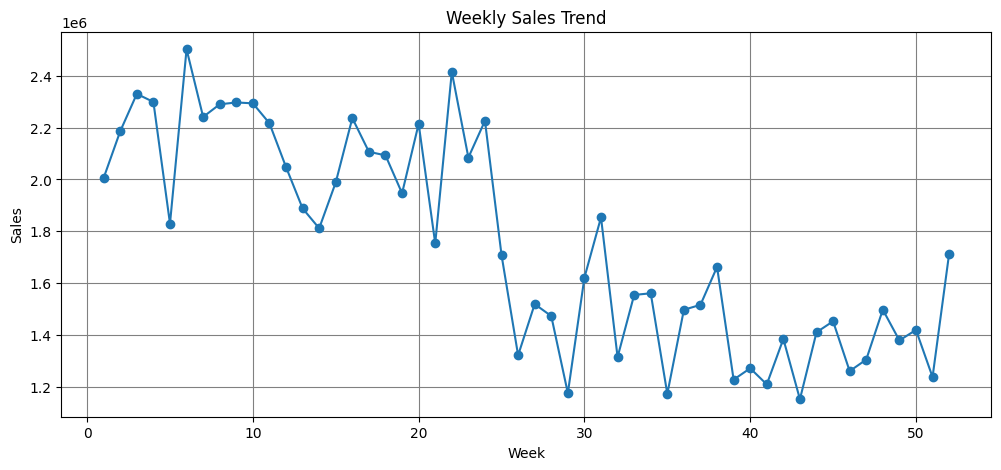

In [76]:
# 19. Create a weekly sales trend graph.

df["Week"] = (df['Order_Date'].dt.isocalendar().week)
# print(df["Week"])

weekly_sales = (
    df.groupby('Week')['Total_Price']
      .sum()
      .reset_index()
)
plt.figure(figsize=(12,5))

plt.plot(
    weekly_sales['Week'],
    weekly_sales['Total_Price'], 
    marker="o"
)
plt.grid(True, color='gray')

plt.title("Weekly Sales Trend")

plt.xlabel("Week")
plt.ylabel("Sales")

plt.show()

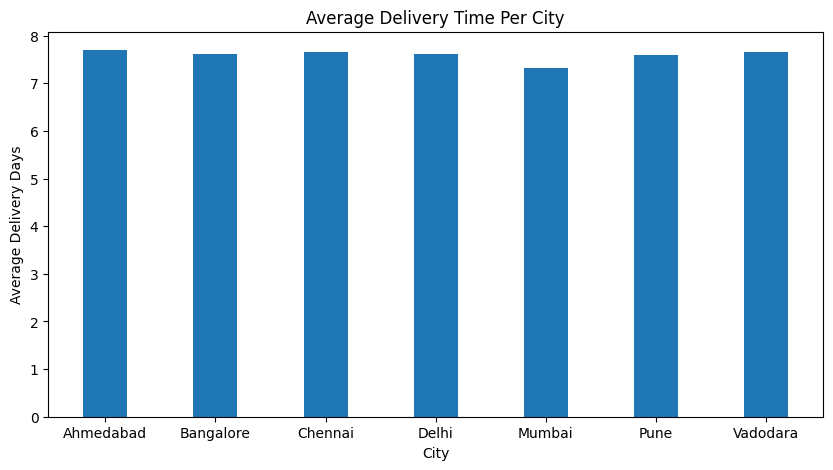

In [82]:
# 20. Create a visualization showing average delivery time per city.

avgDeliveryTime = df.groupby(by="City")["Delivery_Days"].mean().reset_index()

plt.figure(figsize=(10,5))

plt.bar(
    avgDeliveryTime['City'],
    avgDeliveryTime['Delivery_Days'],
    width=0.4
)

plt.title("Average Delivery Time Per City")

plt.xlabel("City")
plt.ylabel("Average Delivery Days")

plt.show()